In [1]:
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"

In [2]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    # "piControl": {"project": "CMIP",        "scenario": "piControl"},
    # "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    # "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    # "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [3]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/home/users/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=50))



In [4]:
"""
BONY DECOMPOSITION SECTION
"""

# =========================
# Physical constants
# =========================
Cp = 1005.0    # J kg-1 K-1
Lv = 2.5e6     # J kg-1
g  = 9.81      # m s-2

# Pressure levels for vertical structure
P_TOP = 10000.0    # 100 hPa
P_SFC = 101300.0   # 1013 hPa
P_MAX = 60000.0    # 600 hPa


# ================================================================
# CORRECTED Bony decomposition functions
# ================================================================

def vertical_integral(da):
    """Mass-weighted vertical integral."""
    da = da.sortby("plev")
    return (da.integrate("plev") / g)


def compute_Phi(plev):
    """Compute prescribed vertical structure Φ(P)."""
    x = (plev - P_TOP) / (P_SFC - P_TOP)
    xm = (P_MAX - P_TOP) / (P_SFC - P_TOP)
    
    Phi = x * (1 - x) * (x - xm)
    Phi = Phi.where((plev >= P_TOP) & (plev <= P_SFC), 0)
    
    dP = np.gradient(plev.values)
    norm = (Phi * dP / g).sum("plev")
    
    return Phi / norm


def compute_omega_bar(wap):
    """Compute ω̄ using mass-weighted vertical integral."""
    return vertical_integral(wap)


def compute_Gamma_q(hus, Phi):
    """Compute Γ_q = -[Φ(P) ∂q/∂P]"""
    dqdp = hus.differentiate("plev")
    return -vertical_integral(Phi * dqdp)


def compute_moisture_advection(ua, va, hus):
    """Compute H_q = -[V·∇q]"""
    lat_rad = np.deg2rad(hus.lat)
    R_earth = 6.371e6  # meters
    
    dlon = np.deg2rad(np.gradient(hus.lon.values)[0])
    dqdlon = hus.differentiate("lon") / dlon
    
    dlat = np.deg2rad(np.gradient(hus.lat.values)[0])
    dqdlat = hus.differentiate("lat") / dlat
    
    cos_lat = np.cos(lat_rad)
    
    adv = (ua / (R_earth * cos_lat) * dqdlon + 
           va / R_earth * dqdlat)
    
    return -vertical_integral(adv)


def compute_Valpha_q(wap, omega_bar_val, Phi, hus):
    """Compute V^α_q = -[(ω - Ω) ∂q/∂P] where Ω = ω̄ * Φ(P)"""
    Omega = omega_bar_val * Phi
    dqdp = hus.differentiate("plev")
    return -vertical_integral((wap - Omega) * dqdp)


def calculate_bony_components(ds_pr, ds_ev, ds_ua, ds_va, ds_wap, ds_hus):
    """
    Calculate all Bony et al. (2013) decomposition components.
    
    Returns dictionary with: P, E, omega_bar, Gamma_q, H_q, Valpha_q
    """
    # Extract variables
    pr = ds_pr['pr'] if isinstance(ds_pr, xr.Dataset) else ds_pr
    E = ds_ev['evspsbl'] if isinstance(ds_ev, xr.Dataset) else ds_ev
    ua = ds_ua['ua'] if isinstance(ds_ua, xr.Dataset) else ds_ua
    va = ds_va['va'] if isinstance(ds_va, xr.Dataset) else ds_va
    wap = ds_wap['wap'] if isinstance(ds_wap, xr.Dataset) else ds_wap
    hus = ds_hus['hus'] if isinstance(ds_hus, xr.Dataset) else ds_hus
    
    # Fill NaNs
    ua = ua.fillna(0)
    va = va.fillna(0)
    wap = wap.fillna(0)
    hus = hus.fillna(0)
    
    print("    Computing Φ(P)...")
    Phi = compute_Phi(wap.plev)
    
    print("    Computing ω̄...")
    omega_bar = compute_omega_bar(wap)
    
    print("    Computing Γ_q...")
    Gamma_q = compute_Gamma_q(hus, Phi)
    
    print("    Computing H_q...")
    H_q = compute_moisture_advection(ua, va, hus)
    
    print("    Computing V^α_q...")
    Valpha_q = compute_Valpha_q(wap, omega_bar, Phi, hus)
    
    return {
        'P': pr,
        'E': E,
        'omega_bar': omega_bar,
        'Gamma_q': Gamma_q,
        'H_q': H_q,
        'Valpha_q': Valpha_q
    }


import os

output_file = "./analysis_transient_data/Bony_decomposition_G6sulfur_minus_SSP245.nc"

if not os.path.exists(output_file):
    print('#'*40)
    print("File does not exist — running code")
    print('#'*40)


    # ================================================================
    # MAIN PROCESSING LOOP 
    # ================================================================
    
    all_results = {}
    
    for model_name, model_meta in MODELS.items():
    
        components_by_exp = {}  # Store all components for each experiment
        seasonal_data = {}      # Store seasonal means by year
    
        # ----------------------------
        # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
        # ----------------------------
        for exp, meta in EXPERIMENTS.items():
    
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
    
            def make_base(vname):
                return (
                    CEDA_BASE
                    / meta["project"]
                    / model_meta["institution"]
                    / model_name
                    / meta["scenario"]
                    / ensemble
                    / "Amon"
                    / vname
                    / model_meta["grid"]
                    / "latest"
                )
    
            base_pr = make_base("pr")
            base_ev = make_base("evspsbl")
            base_ua = make_base("ua")
            base_va = make_base("va")
            base_wap = make_base("wap")
            base_hus = make_base("hus")
            
            ####### Handle ALTERNATE base paths ######
            ds_pr = load_model_data_alt_path(base_pr, meta["project"], model_meta["institution"], 
                                             model_name, meta["scenario"], 
                                             ensemble, model_meta["grid"], mf, "pr")
            ds_ev = load_model_data_alt_path(base_ev, meta["project"], model_meta["institution"], 
                                             model_name, meta["scenario"], 
                                             ensemble, model_meta["grid"], mf, "evspsbl")
            ds_ua = load_model_data_alt_path(base_ua, meta["project"], model_meta["institution"], 
                                             model_name, meta["scenario"], 
                                             ensemble, model_meta["grid"], mf, "ua")
            ds_va = load_model_data_alt_path(base_va, meta["project"], model_meta["institution"], 
                                             model_name, meta["scenario"], 
                                             ensemble, model_meta["grid"], mf, "va")
            ds_wap = load_model_data_alt_path(base_wap, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, "wap")
            ds_hus = load_model_data_alt_path(base_hus, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, "hus")
            
            # Roll and regrid
            ds_pr  = roll_and_regrid(ds_pr)
            ds_ev  = roll_and_regrid(ds_ev)
            ds_ua  = roll_and_regrid(ds_ua)
            ds_va  = roll_and_regrid(ds_va)
            ds_wap  = roll_and_regrid(ds_wap)
            ds_hus = roll_and_regrid(ds_hus)
            
            print(f"  [{model_name}] {exp}: pr loaded {ds_pr.sizes['time']} months "
                  f"({ds_pr.time.values[0]} → {ds_pr.time.values[-1]})")
            print(f"  [{model_name}] {exp}: hus loaded {ds_hus.sizes['time']} months "
                  f"({ds_hus.time.values[0]} → {ds_hus.time.values[-1]})")
    
            # Calculate Bony decomposition components
            print(f"  [{model_name}] {exp}: Computing Bony decomposition...")
            components = calculate_bony_components(ds_pr, ds_ev, ds_ua, ds_va, ds_wap, ds_hus)
            components_by_exp[exp] = components
    
            print(f"  [{model_name}] {exp}: All components computed")
    
        # ----------------------------
        # 2) SEASONAL MEANS BY YEAR FOR EACH COMPONENT
        # ----------------------------
        for exp in components_by_exp:
            seasonal_data[exp] = {}
            
            t_start, t_end = _time_slice(exp)
            
            for comp_name, da in components_by_exp[exp].items():
                # Slice to time period
                da_sliced = da.sel(time=slice(t_start, t_end))
                n_months = da_sliced.sizes['time']
                
                print(f"  [{model_name}] {exp} - {comp_name}: sliced to {n_months} months = "
                      f"{n_months//12} years")
                
                seasonal_data[exp][comp_name] = {
                    "SUM": mf.seasonal_mean_by_year_old(da_sliced, 6, 9),
                    "WIN": mf.seasonal_mean_by_year_old(da_sliced, 11, 2),
                    "ANN": mf.seasonal_mean_by_year_old(da_sliced, 1, 12)
                }
        
        # ----------------------------
        # 3) COMPUTE MEANS FOR EACH EXPERIMENT
        # ----------------------------
        results = {}
        
        for exp in seasonal_data:
            results[exp] = {}
            
            for comp_name in seasonal_data[exp]:
                results[exp][comp_name] = {}
                
                for season in ["SUM", "WIN", "ANN"]:
                    da_year = seasonal_data[exp][comp_name][season]
                    
                    results[exp][comp_name][season] = {
                        "mean": da_year.mean(dim="year"),
                        "std": da_year.std(dim="year")
                    }
    
        # ----------------------------
        # 4) COMPUTE DELTAS (G6sulfur - SSP245)
        # ----------------------------
        EXP1 = "G6sulfur"
        EXP2 = "SSP245"
        
        if EXP1 in results and EXP2 in results:
            results["delta"] = {}
            
            for comp_name in results[EXP1]:
                results["delta"][comp_name] = {}
                
                for season in ["SUM", "WIN", "ANN"]:
                    delta_mean = (results[EXP1][comp_name][season]["mean"] - 
                                 results[EXP2][comp_name][season]["mean"])
                    
                    delta_std = np.sqrt(
                        results[EXP1][comp_name][season]["std"]**2 + 
                        results[EXP2][comp_name][season]["std"]**2
                    )
                    
                    results["delta"][comp_name][season] = {
                        "mean": delta_mean,
                        "std": delta_std
                    }
            
            print(f"  [{model_name}] Delta components computed for all seasons")
            
        # Save results for this model
        all_results[model_name] = results
    
    
    # ================================================================
    # 5) CREATE OUTPUT NETCDF FILE
    # ================================================================
    
    print("\n" + "="*60)
    print("Creating netCDF output file...")
    print("="*60)
    
    # Get coordinates from first model
    first_model = list(all_results.keys())[0]
    sample_da = all_results[first_model]["delta"]["P"]["ANN"]["mean"]
    
    lat = sample_da.lat.values
    lon = sample_da.lon.values
    models = list(all_results.keys())
    
    # Initialize dataset
    ds_out = xr.Dataset(
        coords={
            'lat': lat,
            'lon': lon,
            'model': models
        }
    )
    
    # Add metadata
    ds_out.attrs['title'] = 'Bony et al. (2013) Precipitation Decomposition'
    ds_out.attrs['description'] = 'Decomposition of ΔP (G6sulfur - SSP245) into thermodynamic and dynamic components'
    ds_out.attrs['reference'] = 'Bony, S., Bellon, G., Klocke, D. et al. (2013) Nature Clim Change 3, 245-249'
    ds_out.attrs['created'] = str(np.datetime64('now'))
    
    seasons = ["SUM", "WIN", "ANN"]
    season_names = {"SUM": "JJA (Jun-Jul-Aug)", "WIN": "DJF (Dec-Jan-Feb)", "ANN": "Annual"}
    
    for season in seasons:
        
        season_name = season_names[season]
        
        # Initialize arrays
        n_models = len(models)
        n_lat = len(lat)
        n_lon = len(lon)
        
        # Allocate arrays
        delta_P = np.zeros((n_models, n_lat, n_lon))
        delta_E = np.zeros((n_models, n_lat, n_lon))
        delta_omega_bar = np.zeros((n_models, n_lat, n_lon))
        delta_Gamma_q = np.zeros((n_models, n_lat, n_lon))
        delta_H_q = np.zeros((n_models, n_lat, n_lon))
        delta_Valpha_q = np.zeros((n_models, n_lat, n_lon))
        
        # Reference state (SSP245 mean)
        omega_bar_ref = np.zeros((n_models, n_lat, n_lon))
        Gamma_q_ref = np.zeros((n_models, n_lat, n_lon))
        
        # Fill arrays
        for i, model in enumerate(models):
            res = all_results[model]
            
            delta_P[i] = res["delta"]["P"][season]["mean"].values
            delta_E[i] = res["delta"]["E"][season]["mean"].values
            delta_omega_bar[i] = res["delta"]["omega_bar"][season]["mean"].values
            delta_Gamma_q[i] = res["delta"]["Gamma_q"][season]["mean"].values
            delta_H_q[i] = res["delta"]["H_q"][season]["mean"].values
            delta_Valpha_q[i] = res["delta"]["Valpha_q"][season]["mean"].values
            
            omega_bar_ref[i] = res["SSP245"]["omega_bar"][season]["mean"].values
            Gamma_q_ref[i] = res["SSP245"]["Gamma_q"][season]["mean"].values
        
        # Compute decomposition terms
        # ΔP_therm = ΔE + ω̄*ΔΓ_q + ΔH_q + ΔV^α_q
        delta_P_therm = (delta_E + 
                        omega_bar_ref * delta_Gamma_q + 
                        delta_H_q + 
                        delta_Valpha_q)
        
        # ΔP_dyn = Γ_q*Δω̄
        delta_P_dyn = Gamma_q_ref * delta_omega_bar
        
        # Total
        delta_P_total = delta_P_therm + delta_P_dyn
        
        # ===== LEFT HAND SIDE (LHS) =====
        ds_out[f'LHS_delta_P_{season}'] = (
            ['model', 'lat', 'lon'], delta_P,
            {'long_name': f'[LHS] Total precipitation change ({season_name})',
             'units': 'kg m-2 s-1',
             'description': 'Direct difference: P(G6sulfur) - P(SSP245)'}
        )
        
        # ===== RIGHT HAND SIDE (RHS) - THERMODYNAMIC =====
        ds_out[f'RHS_delta_P_therm_{season}'] = (
            ['model', 'lat', 'lon'], delta_P_therm,
            {'long_name': f'[RHS] Thermodynamic component ({season_name})',
             'units': 'kg m-2 s-1',
             'formula': 'ΔE + ω̄*ΔΓ_q + ΔH_q + ΔV^α_q'}
        )
        
        # Individual thermodynamic terms
        ds_out[f'RHS_therm_delta_E_{season}'] = (
            ['model', 'lat', 'lon'], delta_E,
            {'long_name': f'[Therm] Evaporation change ({season_name})',
             'units': 'kg m-2 s-1',
             'term': '1 of 4 in thermodynamic component'}
        )
        
        ds_out[f'RHS_therm_omega_bar_times_delta_Gamma_q_{season}'] = (
            ['model', 'lat', 'lon'], omega_bar_ref * delta_Gamma_q,
            {'long_name': f'[Therm] ω̄*ΔΓ_q ({season_name})',
             'units': 'kg m-2 s-1',
             'term': '2 of 4 in thermodynamic component',
             'description': 'Mean circulation × change in moisture stratification'}
        )
        
        ds_out[f'RHS_therm_delta_H_q_{season}'] = (
            ['model', 'lat', 'lon'], delta_H_q,
            {'long_name': f'[Therm] Horizontal advection change ({season_name})',
             'units': 'kg m-2 s-1',
             'term': '3 of 4 in thermodynamic component'}
        )
        
        ds_out[f'RHS_therm_delta_Valpha_q_{season}'] = (
            ['model', 'lat', 'lon'], delta_Valpha_q,
            {'long_name': f'[Therm] Residual vertical advection change ({season_name})',
             'units': 'kg m-2 s-1',
             'term': '4 of 4 in thermodynamic component'}
        )
        
        # ===== RIGHT HAND SIDE (RHS) - DYNAMIC =====
        ds_out[f'RHS_delta_P_dyn_{season}'] = (
            ['model', 'lat', 'lon'], delta_P_dyn,
            {'long_name': f'[RHS] Dynamic component ({season_name})',
             'units': 'kg m-2 s-1',
             'formula': 'Γ_q*Δω̄',
             'description': 'Moisture stratification × change in mean circulation'}
        )
        
        ds_out[f'RHS_dyn_Gamma_q_times_delta_omega_bar_{season}'] = (
            ['model', 'lat', 'lon'], Gamma_q_ref * delta_omega_bar,
            {'long_name': f'[Dyn] Γ_q*Δω̄ ({season_name})',
             'units': 'kg m-2 s-1',
             'term': 'Full dynamic component'}
        )
        
        # ===== TOTAL (sum of RHS terms) =====
        ds_out[f'RHS_delta_P_total_{season}'] = (
            ['model', 'lat', 'lon'], delta_P_total,
            {'long_name': f'[RHS] Total reconstructed change ({season_name})',
             'units': 'kg m-2 s-1',
             'formula': 'delta_P_therm + delta_P_dyn',
             'description': 'Should equal LHS_delta_P if decomposition is exact'}
        )
        
        # ===== RESIDUAL (LHS - RHS) =====
        residual = delta_P - delta_P_total
        ds_out[f'residual_{season}'] = (
            ['model', 'lat', 'lon'], residual,
            {'long_name': f'Residual (LHS - RHS) ({season_name})',
             'units': 'kg m-2 s-1',
             'description': 'Difference between direct change and reconstructed change'}
        )
        
        # ===== INDIVIDUAL DELTAS (for reference) =====
        ds_out[f'delta_omega_bar_{season}'] = (
            ['model', 'lat', 'lon'], delta_omega_bar,
            {'long_name': f'Change in mean vertical velocity ({season_name})',
             'units': 'Pa s-1'}
        )
        
        ds_out[f'delta_Gamma_q_{season}'] = (
            ['model', 'lat', 'lon'], delta_Gamma_q,
            {'long_name': f'Change in moisture stratification ({season_name})',
             'units': 'kg kg-1'}
        )
        
        # ===== REFERENCE STATE (SSP245) =====
        ds_out[f'omega_bar_ref_{season}'] = (
            ['model', 'lat', 'lon'], omega_bar_ref,
            {'long_name': f'Reference ω̄ (SSP245, {season_name})',
             'units': 'Pa s-1'}
        )
        
        ds_out[f'Gamma_q_ref_{season}'] = (
            ['model', 'lat', 'lon'], Gamma_q_ref,
            {'long_name': f'Reference Γ_q (SSP245, {season_name})',
             'units': 'kg kg-1'}
        )
    
    # Save to file
    # output_file = "Bony_decomposition_G6sulfur_minus_SSP245.nc"
    print(f"\nSaving to {output_file}...")
    ds_out.to_netcdf(output_file)
    print(f"✓ Done! File saved with {len(ds_out.data_vars)} variables.")
    print(f"  Models: {len(models)}")
    print(f"  Seasons: {len(seasons)} (SUM, WIN, ANN)")
    print(f"  Grid: {len(lat)} lat × {len(lon)} lon")

else:
    print('#'*40)
    print(f"{output_file} already exists — skipping its computation")
    print('#'*40)

########################################
./analysis_transient_data/Bony_decomposition_G6sulfur_minus_SSP245.nc already exists — skipping its computation
########################################


In [5]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pr_comp=xr.open_dataset(output_file)

In [6]:
print("pr_comp",pr_comp)

pr_comp <xarray.Dataset> Size: 10MB
Dimensions:                                      (lat: 41, lon: 144, model: 5)
Coordinates:
  * lat                                          (lat) float64 328B -50.0 ......
  * lon                                          (lon) float64 1kB -180.0 ......
  * model                                        (model) <U13 260B 'UKESM1-0-...
Data variables: (12/42)
    LHS_delta_P_SUM                              (model, lat, lon) float64 236kB ...
    RHS_delta_P_therm_SUM                        (model, lat, lon) float64 236kB ...
    RHS_therm_delta_E_SUM                        (model, lat, lon) float64 236kB ...
    RHS_therm_omega_bar_times_delta_Gamma_q_SUM  (model, lat, lon) float64 236kB ...
    RHS_therm_delta_H_q_SUM                      (model, lat, lon) float64 236kB ...
    RHS_therm_delta_Valpha_q_SUM                 (model, lat, lon) float64 236kB ...
    ...                                           ...
    RHS_delta_P_total_ANN                

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_map(
    da,
    title=None,
    cmap='coolwarm',
    figsize=(12, 6),
    vmin=None,
    vmax=None,
    add_colorbar=True
):
    """
    Plot an xarray DataArray on a global map using cartopy.

    Parameters
    ----------
    da : xarray.DataArray
        Must have 'lat' and 'lon' coordinates.
    title : str, optional
        Plot title.
    cmap : str
        Colormap.
    figsize : tuple
        Figure size.
    vmin, vmax : float, optional
        Color scale limits.
    add_colorbar : bool
        Whether to draw colorbar.
    """

    # Ensure 2D (remove singleton dims like 'model')
    da = da.squeeze()

    # Fix longitude if needed (0–360 → -180–180)
    if da.lon.max() > 180:
        da = da.assign_coords(
            lon=((da.lon + 180) % 360) - 180
        ).sortby('lon')

    # Ensure latitude is increasing
    if da.lat[0] > da.lat[-1]:
        da = da.sortby('lat')

    # Create figure
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot
    # im = ax.pcolormesh(
    #     da.lon,
    #     da.lat,
    #     da,
    #     transform=ccrs.PlateCarree(),
    #     cmap=cmap,
    #     vmin=vmin,
    #     vmax=vmax
    # )
    im = ax.contourf(
        da.lon, 
        da.lat, 
        da,     
        transform=ccrs.PlateCarree(),
        levels=np.linspace(vmin, vmax, 21),      
        cmap='RdBu_r', extend='both')

    # Features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Gridlines with labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Colorbar
    if add_colorbar:
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)
        cbar.set_label(da.name if da.name else '')

    # Title
    if title:
        plt.title(title)
    else:
        plt.title(da.name if da.name else '')

    plt.show()

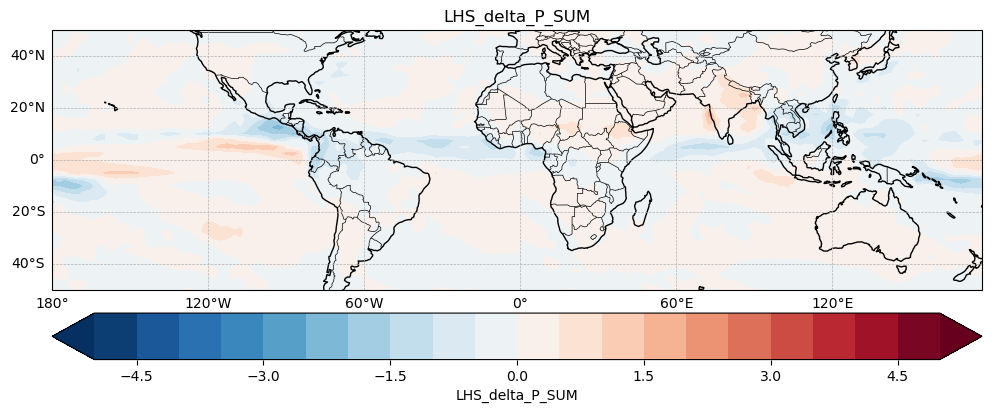

In [8]:
da = pr_comp['LHS_delta_P_SUM'].sel(model='UKESM1-0-LL')*86400
plot_map(da, vmin=-5, vmax=5)

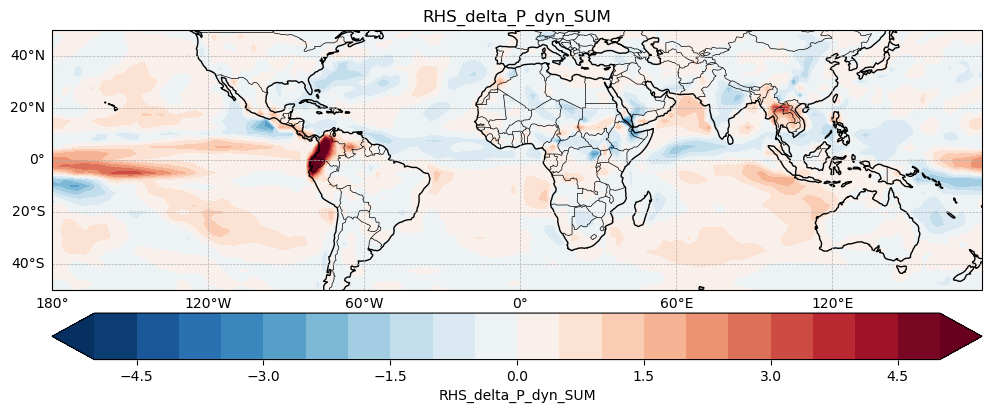

In [9]:
da = pr_comp['RHS_delta_P_dyn_SUM'].sel(model='UKESM1-0-LL')*86400
plot_map(da, vmin=-5, vmax=5)

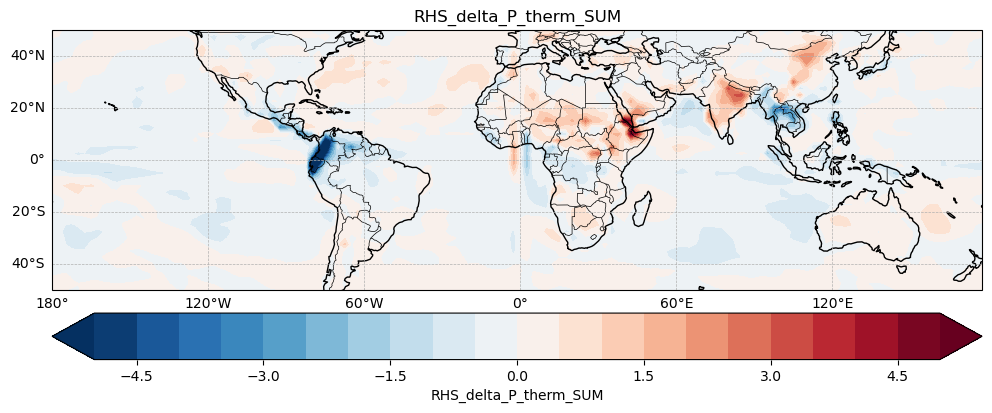

In [10]:
da = pr_comp['RHS_delta_P_therm_SUM'].sel(model='UKESM1-0-LL')*86400
plot_map(da, vmin=-5, vmax=5)

In [11]:
def compute_regional_map(
    pr_comp,
    component_name,
    season="stitched",
    trop_bound=50,
    land_mask=None,
    agreement_threshold=4,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    """
    Plot regional map from Bony decomposition netCDF file.
    
    Parameters
    ----------
    pr_comp : xr.Dataset
        Bony decomposition dataset (e.g., from 'Bony_decomposition_G6sulfur_minus_SSP245.nc')
    component_name : str
        Component to plot. Options:
        - 'LHS_delta_P' : Total precipitation change
        - 'RHS_delta_P_therm' : Thermodynamic component
        - 'RHS_delta_P_dyn' : Dynamic component
        - 'RHS_delta_P_total' : Total reconstructed change
        - 'RHS_therm_delta_E' : Evaporation term
        - 'RHS_therm_omega_bar_times_delta_Gamma_q' : ω̄*ΔΓ_q term
        - 'RHS_therm_delta_H_q' : Horizontal advection term
        - 'RHS_therm_delta_Valpha_q' : Residual vertical advection term
        - 'RHS_dyn_Gamma_q_times_delta_omega_bar' : Dynamic term
        - 'residual' : LHS - RHS residual
    season : str, default 'stitched'
        Season to plot: 
        - 'stitched' : SUM for NH (lat>0), WIN for SH (lat<=0)
        - 'SUM' : JJA only
        - 'WIN' : DJF only
        - 'ANN' : Annual mean
    trop_bound : int, default 50
        Latitude boundary (not used when reading from netCDF, but kept for compatibility)
    land_mask : optional
        Land mask (not currently used)
    agreement_threshold : int, default 3
        Number of models that must agree on sign for stippling
    plot : bool, default True
        Whether to create the plot
    save_fig : bool, default False
        Whether to save the figure
    fig_path : str, optional
        Path to save figure
    
    Returns
    -------
    delta_mean : xr.DataArray
        Multi-model mean of the selected component
    stipple_mask : np.ndarray
        Boolean mask for model agreement stippling
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import cartopy.io.shapereader as shpreader
    import xarray as xr
    import warnings
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    import matplotlib.patches as mpatches
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    # ------------------------------------------------------------------ #
    # Handle stitched vs single season
    # ------------------------------------------------------------------ #
    if season.lower() == "stitched":
        # Load both SUM and WIN
        var_name_sum = f"{component_name}_SUM"
        var_name_win = f"{component_name}_WIN"
        
        if var_name_sum not in pr_comp or var_name_win not in pr_comp:
            raise ValueError(
                f"Variables '{var_name_sum}' or '{var_name_win}' not found in dataset. "
                f"Available variables: {list(pr_comp.data_vars)}"
            )
        
        data_sum = pr_comp[var_name_sum]  # (model, lat, lon)
        data_win = pr_comp[var_name_win]  # (model, lat, lon)
        
        # Stitch: NH (lat > 0) = SUM, SH (lat <= 0) = WIN
        lat = data_sum.lat
        # Apply stitching - this preserves (model, lat, lon) dimension order
        stacked = xr.where(lat > 0, data_sum, data_win)
        
        season_label = "NH: JJA, SH: DJF"
        
    else:
        # Single season
        var_name = f"{component_name}_{season}"
        
        if var_name not in pr_comp:
            raise ValueError(
                f"Variable '{var_name}' not found in dataset. "
                f"Available variables: {list(pr_comp.data_vars)}"
            )
        
        stacked = pr_comp[var_name]  # (model, lat, lon)
        
        season_labels = {'SUM': 'JJA', 'WIN': 'DJF', 'ANN': 'Annual'}
        season_label = season_labels.get(season, season)
    
    # Ensure dimension order is (model, lat, lon)
    if 'model' in stacked.dims:
        stacked = stacked.transpose('model', 'lat', 'lon')
    
    # ------------------------------------------------------------------ #
    # Multi-model mean and stippling mask
    # ------------------------------------------------------------------ #
    delta_mean = stacked.mean(dim="model").squeeze()
    
    sign_mean = np.sign(delta_mean.values)
    sign_models = np.sign(stacked.values)
    
    # sign_models shape: (model, lat, lon)
    # sign_mean shape: (lat, lon)
    # Need to broadcast: (model, lat, lon) == (1, lat, lon)
    n_agree = np.sum(sign_models == sign_mean[np.newaxis, :, :], axis=0)
    stipple_mask = n_agree >= agreement_threshold
    
    n_models = stacked.sizes['model']
    
    lat = delta_mean.lat.values
    lon = delta_mean.lon.values
    data = delta_mean.values
    LON, LAT = np.meshgrid(lon, lat)
    
    # Convert from kg m-2 s-1 to mm/day
    data_mm_day = data * 86400
    
    # ------------------------------------------------------------------ #
    # Plot
    # ------------------------------------------------------------------ #
    if plot:
        # vmax = float(np.nanpercentile(np.abs(data_mm_day), 98))
        vmax=0.5
        vmin = -vmax
        levels = np.linspace(-vmax, vmax, 21)
        
        fig, ax = plt.subplots(figsize=(10, 5),
                               subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.set_global()
        
        im = ax.contourf(LON, LAT, data_mm_day, levels=levels, cmap='RdBu_r',
                         extend='both', transform=ccrs.PlateCarree())
        
        # Stippling
        stip_lat_flat = LAT[stipple_mask].ravel()[::2]
        stip_lon_flat = LON[stipple_mask].ravel()[::2]
        ax.scatter(stip_lon_flat, stip_lat_flat,
                   s=1.5, color="black", alpha=0.5, zorder=5)
        
        # Coastlines
        try:
            shpfilename = shpreader.natural_earth(
                resolution="110m", category="physical", name="coastline"
            )
            reader = shpreader.Reader(shpfilename)
            for geom in reader.geometries():
                if hasattr(geom, "geoms"):
                    for g in geom.geoms:
                        ax.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
                else:
                    ax.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
        except Exception:
            pass
        
        cbar = plt.colorbar(im, ax=ax, orientation="horizontal", 
                            pad=0.05, shrink=1.0, aspect=40)
        
        # Get component label for plot
        component_labels = {
            'LHS_delta_P': 'Total ΔP',
            'RHS_delta_P_therm': 'Thermodynamic Component',
            'RHS_delta_P_dyn': 'Dynamic Component ($\Gamma_q \cdot \Delta \overline{\omega}$)',
            'RHS_delta_P_total': 'Total Reconstructed ΔP',
            'RHS_therm_delta_E': 'ΔE (Evaporation)',
            'RHS_therm_omega_bar_times_delta_Gamma_q': '$\overline{\omega} \cdot \Delta \Gamma_q$',
            'RHS_therm_delta_H_q': '$\Delta H_q$ (Horiz. Advection)',
            'RHS_therm_delta_Valpha_q': '$\Delta V^α_q$ (Resid. Vert. Advection)',
            'RHS_dyn_Gamma_q_times_delta_omega_bar': 'Γ_q·Δω̄', #Not needed, it is the dyn component
            'residual': 'Residual (LHS - RHS)'
        }
        
        comp_label = component_labels.get(component_name, component_name)
        
        cbar.set_label(f"{comp_label}  [mm day⁻¹]", fontsize=10)
        
        # Equator line
        ax.plot([float(lon.min()), float(lon.max())], [0, 0],
                color='gray', linewidth=0.8, linestyle='--',
                transform=ccrs.PlateCarree())
        
        ax.set_extent([float(lon.min()), float(lon.max()),
                       float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
        ax.set_aspect('auto')
        
        ax.set_xticks(np.arange(np.floor(float(lon.min())),
                                np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(np.floor(float(lat.min())),
                                np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=8)
        
        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
        ax.set_title(
            f"Multi-model mean: {comp_label}  ({season_label})\n"
            f"G6sulfur - SSP245  |  "
            f"stippling = {agreement_threshold}/{n_models} model sign agreement",
            fontsize=11
        )
        ax.grid(True, linewidth=0.3, alpha=0.4)
        
        # Bombardi and Boos 2021 regions
        regions = {
            'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
            'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
            'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
            'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
            'India':        {'lon': (73,  87),   'lat': (15,    27)},
            'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
        }
        for name, coords in regions.items():
            lon0, lon1 = coords['lon']
            lat0, lat1 = coords['lat']
            rect = mpatches.Rectangle(
                (lon0, lat0), lon1-lon0, lat1-lat0,
                linewidth=1.2, edgecolor='black', facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax.add_patch(rect)
            ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
                    fontsize=8, ha='center', va='top',
                    transform=ccrs.PlateCarree())
        
        plt.tight_layout()
        plt.show()
        
        if save_fig:
            season_suffix = "stitched" if season.lower() == "stitched" else season
            path = fig_path or f"{component_name}_{season_suffix}_G6sulfur_minus_SSP245.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")
    
    season_suffix = "stitched" if season.lower() == "stitched" else season
    # print(f"Returning → {component_name}_{season_suffix}")
    return delta_mean, stipple_mask

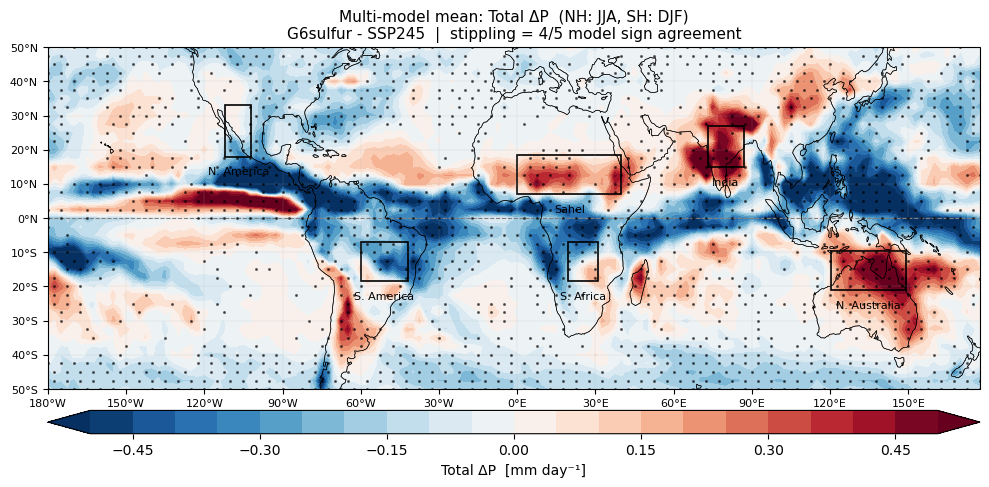

In [12]:
# Plot total precipitation change (annual)
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='LHS_delta_P',
    # season='stitched'  # This is the default
)

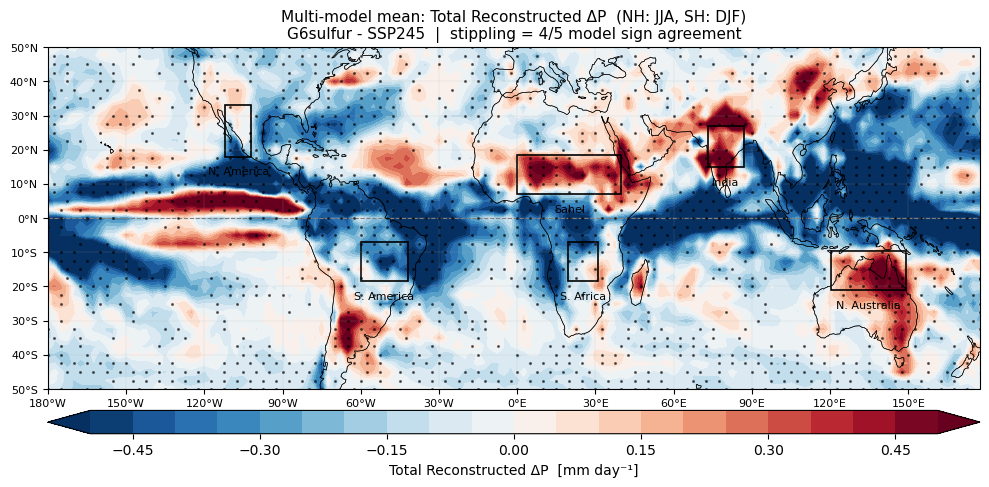

In [13]:
# Plot total precipitation change (annual)
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_delta_P_total',
    # season='stitched'  # This is the default
)

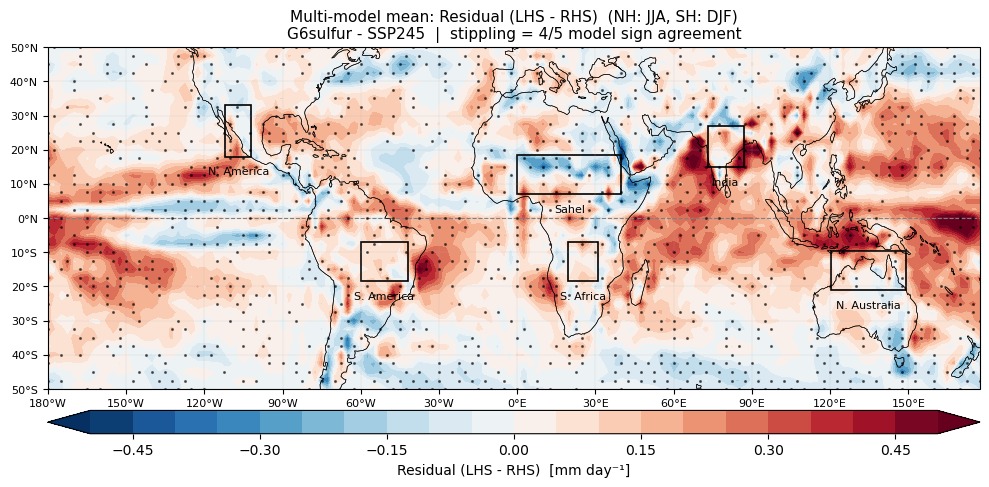

In [14]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='residual',
    # season='stitched'  # This is the default
)

        component_labels = {
            'LHS_delta_P': 'Total ΔP',
            'RHS_delta_P_therm': 'Thermodynamic Component',
            'RHS_delta_P_dyn': 'Dynamic Component ($\Gamma_q\dot\Delta\bar{omega}'$)',
            'RHS_delta_P_total': 'Total Reconstructed ΔP',
            'RHS_therm_delta_E': 'ΔE (Evaporation)',
            'RHS_therm_omega_bar_times_delta_Gamma_q': 'ω̄·ΔΓ_q',
            'RHS_therm_delta_H_q': 'ΔH_q (Horiz. Advection)',
            'RHS_therm_delta_Valpha_q': 'ΔV^α_q (Resid. Vert. Advection)',
            'RHS_dyn_Gamma_q_times_delta_omega_bar': 'Γ_q·Δω̄',
            'residual': 'Residual (LHS - RHS)'
        }
        

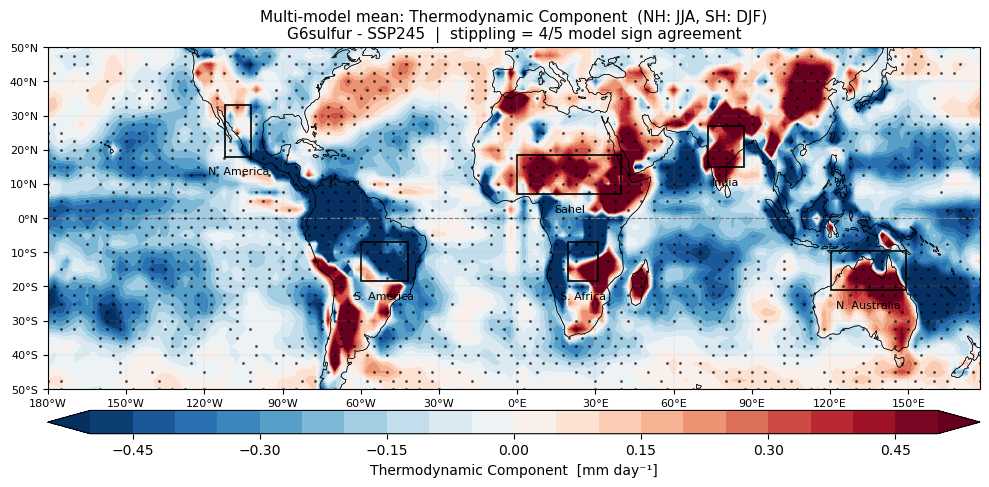

In [15]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_delta_P_therm',
    # season='stitched'  # This is the default
)

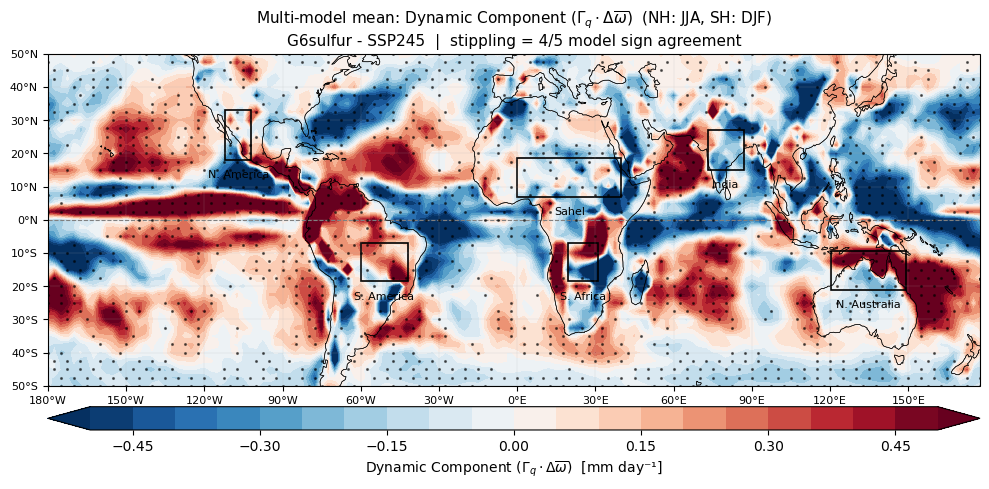

In [16]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_delta_P_dyn',
    # season='stitched'  # This is the default
)

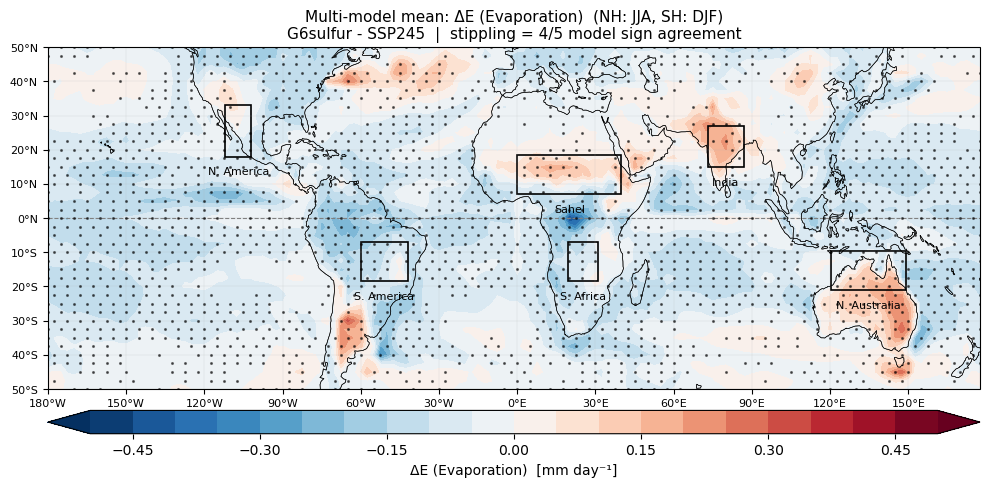

In [17]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_therm_delta_E',
    # season='stitched'  # This is the default
)

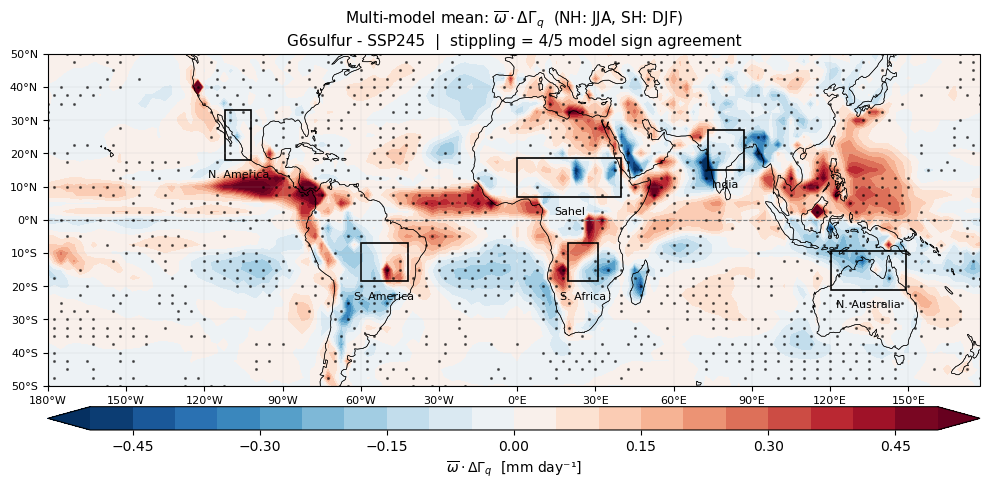

In [18]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_therm_omega_bar_times_delta_Gamma_q',
    # season='stitched'  # This is the default
)

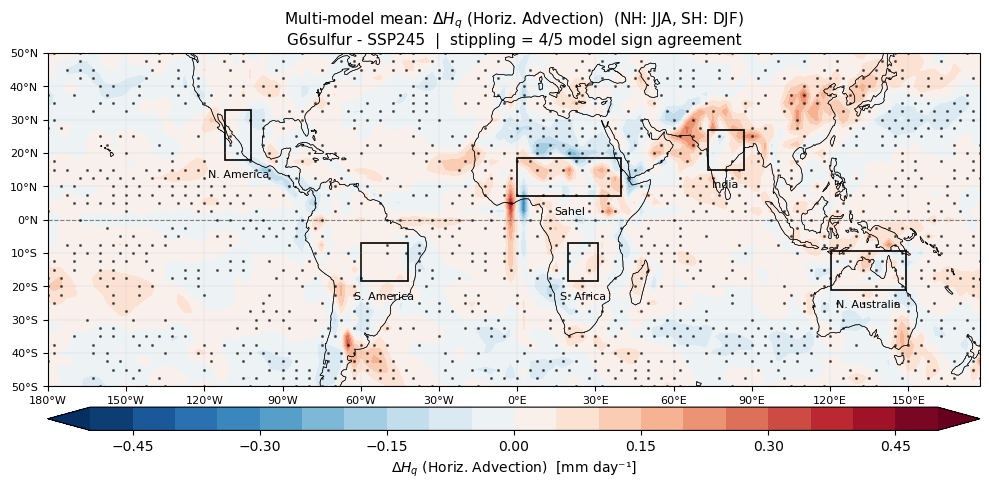

In [19]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_therm_delta_H_q',
    # season='stitched'  # This is the default
)

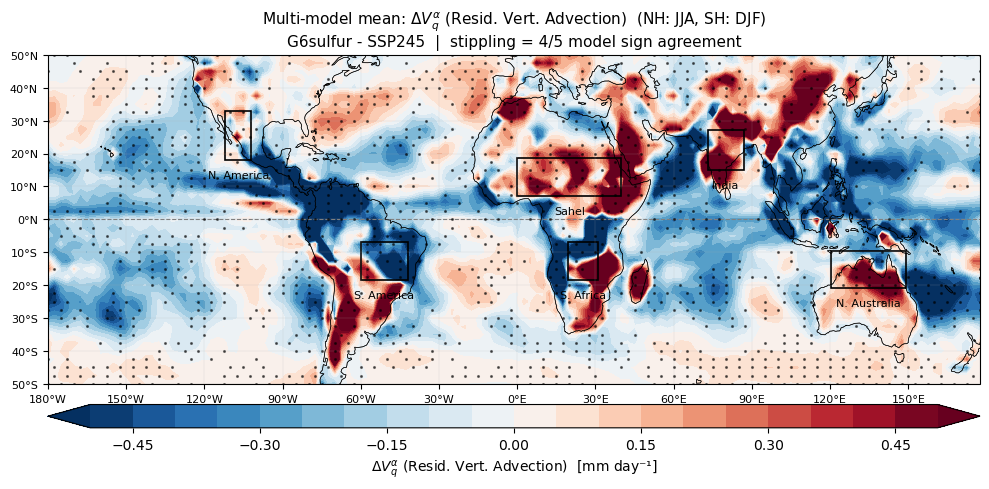

In [20]:

# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_therm_delta_Valpha_q',
    # season='stitched'  # This is the default
)

# To plot the Φ(P) vertical profile

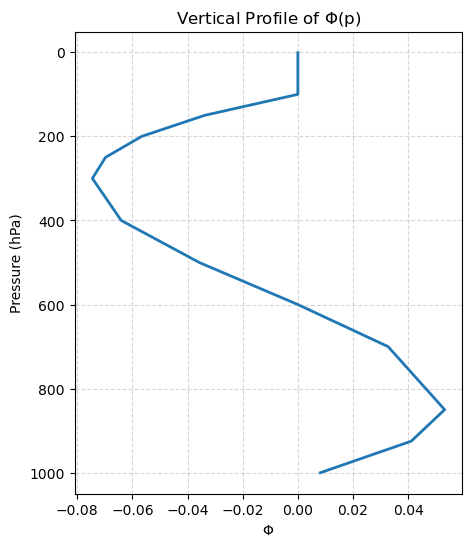

In [21]:
lev_data=xr.open_dataset('/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest/wap_Amon_UKESM1-0-LL_G6sulfur_r1i1p1f2_gn_202001-204912.nc')
Phi_profile=compute_Phi(lev_data['wap'].plev)

import matplotlib.pyplot as plt

def plot_profile(Phi_profile, xlabel='$\Phi$', ylabel='Pressure (hPa)', title=None):
    fig, ax = plt.subplots(figsize=(5, 6))

    # Line plot instead of scatter
    ax.plot(Phi_profile*100, Phi_profile.plev/100, linewidth=2)

    # Invert y-axis (pressure decreases upward)
    ax.invert_yaxis()

    # Labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Optional title
    if title:
        ax.set_title(title)

    # Grid for readability
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.show()

plot_profile(Phi_profile, title='Vertical Profile of $\Phi$(p)')

In [22]:
def plot_regional_decomposition_bars(
    pr_comp,
    set_1,
    set_2,
    season="stitched",
    plot_type="percentage",  # 'percentage' or 'absolute'
    show_error_bars=True,
    agreement_threshold=4,
    figsize=(12, 6),
    save_fig=False,
    fig_path=None,
):
    """
    Plot bar chart showing decomposition components for monsoon regions.
    
    Parameters
    ----------
    pr_comp : xr.Dataset
        Bony decomposition dataset
    set_1 : list of str
        Component(s) to use as denominator/total (e.g., ['LHS_delta_P'])
    set_2 : list of str
        Component(s) to decompose (e.g., ['RHS_delta_P_therm', 'RHS_delta_P_dyn'])
    season : str, default 'stitched'
        'stitched', 'SUM', 'WIN', or 'ANN'
    plot_type : str, default 'percentage'
        'percentage' (% contribution) or 'absolute' (mm/day)
    show_error_bars : bool, default True
        Whether to show model spread as error bars
    agreement_threshold : int, default 4
        Minimum models for agreement (not used in bars, kept for compatibility)
    figsize : tuple, default (12, 6)
        Figure size
    save_fig : bool, default False
        Whether to save figure
    fig_path : str, optional
        Path to save figure
    
    Returns
    -------
    fig, ax : matplotlib figure and axes
    regional_data : dict
        Dictionary with regional mean values and spreads
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import xarray as xr
    
    # Bombardi and Boos 2021 regions
    regions = {
        'N. America':   {'lon': (-112, -102),  'lat': (18,    33)},
        'S. America':   {'lon': (-60,  -42),   'lat': (-18.5, -7)},
        'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
        'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
        'India':        {'lon': (73,  87),   'lat': (15,    27)},
        'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
    }
    
    component_labels = {
        'LHS_delta_P': 'Total ΔP',
        'RHS_delta_P_therm': 'Thermodynamic',
        'RHS_delta_P_dyn': 'Dynamic',
        'RHS_delta_P_total': 'Reconstructed ΔP',
        'RHS_therm_delta_E': 'ΔE',
        'RHS_therm_omega_bar_times_delta_Gamma_q': r'$\overline{\omega} \cdot \Delta \Gamma_q$',
        'RHS_therm_delta_H_q': r'$\Delta H_q$',
        'RHS_therm_delta_Valpha_q': r'$\Delta V^{\alpha}_q$',
        'RHS_dyn_Gamma_q_times_delta_omega_bar': r'$\Gamma_q \cdot \Delta\overline{\omega}$',
        'residual': 'Residual'
    }
    
    # ------------------------------------------------------------------ #
    # Extract data for each component
    # ------------------------------------------------------------------ #
    def get_component_data(component_name, season):
        """Get stitched or single season data for a component."""
        if season.lower() == "stitched":
            var_name_sum = f"{component_name}_SUM"
            var_name_win = f"{component_name}_WIN"
            
            data_sum = pr_comp[var_name_sum]
            data_win = pr_comp[var_name_win]
            
            lat = data_sum.lat
            stacked = xr.where(lat > 0, data_sum, data_win)
        else:
            var_name = f"{component_name}_{season}"
            stacked = pr_comp[var_name]
        
        if 'model' in stacked.dims:
            stacked = stacked.transpose('model', 'lat', 'lon')
        
        return stacked * 86400  # Convert to mm/day
    
    # ------------------------------------------------------------------ #
    # Compute regional means
    # ------------------------------------------------------------------ #
    regional_data = {}
    
    for region_name, coords in regions.items():
        regional_data[region_name] = {}
        
        lon0, lon1 = coords['lon']
        lat0, lat1 = coords['lat']
        
        # Handle longitude wrapping (e.g., 248-258 crosses 360->0)
        for comp_name in set_1 + set_2:
            data = get_component_data(comp_name, season)
            
            # Select region (simple case, no wrapping needed)
            mask_lon = (data.lon >= lon0) & (data.lon <= lon1)
            mask_lat = (data.lat >= lat0) & (data.lat <= lat1)
            
            # Select and compute regional mean for each model
            regional = data.where(mask_lat & mask_lon, drop=True)
            regional_mean_per_model = regional.mean(dim=['lat', 'lon'])
            
            # Multi-model mean and std
            mean_val = regional_mean_per_model.mean(dim='model').values
            std_val = regional_mean_per_model.std(dim='model').values
            
            regional_data[region_name][comp_name] = {
                'mean': mean_val,
                'std': std_val
            }
    
    # ------------------------------------------------------------------ #
    # Compute percentages if needed
    # ------------------------------------------------------------------ #
    if plot_type == "percentage":
        # Compute percentages WHILE PRESERVING SIGN RELATIVE TO ABSOLUTE VALUES
        for region_name in regional_data:
            total = sum(regional_data[region_name][comp]['mean'] for comp in set_1)
            
            for comp in set_2:
                if abs(total) > 1e-10:  # Avoid division by zero
                    # Use abs(total) to preserve the original sign direction
                    regional_data[region_name][comp]['percentage'] = (
                        regional_data[region_name][comp]['mean'] / abs(total) * 100
                    )
                    # Error propagation
                    regional_data[region_name][comp]['percentage_std'] = (
                        regional_data[region_name][comp]['std'] / abs(total) * 100
                    )
                else:
                    regional_data[region_name][comp]['percentage'] = 0
                    regional_data[region_name][comp]['percentage_std'] = 0
    
    # ------------------------------------------------------------------ #
    # Plot
    # ------------------------------------------------------------------ #
    fig, ax = plt.subplots(figsize=figsize)
    
    region_names = list(regions.keys())
    x = np.arange(len(region_names))
    width = 0.8 / len(set_2)
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(set_2)))
    
    if plot_type == "percentage":
        # Separate positive and negative contributions
        pos_bottom = np.zeros(len(region_names))
        neg_bottom = np.zeros(len(region_names))
        
        for i, comp in enumerate(set_2):
            values = np.array([regional_data[reg][comp]['percentage'] for reg in region_names])
            errors = [regional_data[reg][comp]['percentage_std'] for reg in region_names] if show_error_bars else None
            
            label = component_labels.get(comp, comp)
            
            # Determine if positive or negative
            pos_values = np.where(values >= 0, values, 0)
            neg_values = np.where(values < 0, values, 0)
            
            # Plot positive contributions stacked upward
            if np.any(pos_values > 0):
                ax.bar(x, pos_values, width=0.6, bottom=pos_bottom, 
                       label=label, color=colors[i], alpha=0.8,
                       edgecolor='black', linewidth=0.5)
                pos_bottom += pos_values
            
            # Plot negative contributions stacked downward
            if np.any(neg_values < 0):
                ax.bar(x, neg_values, width=0.6, bottom=neg_bottom,
                       color=colors[i], alpha=0.8,
                       edgecolor='black', linewidth=0.5)
                neg_bottom += neg_values
            
            if show_error_bars and errors is not None:
                ax.errorbar(x, values, yerr=errors, fmt='none', 
                           ecolor='black', elinewidth=1, capsize=3, alpha=0.6)
        
        ax.set_ylabel('Contribution (%)', fontsize=12)
        ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        # Add reference line name
        total_label = ' + '.join([component_labels.get(c, c) for c in set_1])
        ax.text(0.02, 0.98, f'Relative to: {total_label}', 
               transform=ax.transAxes, fontsize=9, va='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        
    else:  # absolute
        # Grouped bars for absolute values
        for i, comp in enumerate(set_2):
            values = [regional_data[reg][comp]['mean'] for reg in region_names]
            errors = [regional_data[reg][comp]['std'] for reg in region_names] if show_error_bars else None
            
            label = component_labels.get(comp, comp)
            offset = (i - len(set_2)/2 + 0.5) * width
            
            bars = ax.bar(x + offset, values, width, 
                         label=label, color=colors[i], alpha=0.8,
                         edgecolor='black', linewidth=0.5,
                         yerr=errors if show_error_bars else None,
                         capsize=3, error_kw={'elinewidth': 1, 'alpha': 0.6})
        
        ax.set_ylabel('ΔP (mm day⁻¹)', fontsize=12)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    ax.set_xlabel('Monsoon Region', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(region_names, rotation=15, ha='right')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    
    season_labels = {'stitched': 'NH: JJA, SH: DJF', 'SUM': 'JJA', 'WIN': 'DJF', 'ANN': 'Annual'}
    season_label = season_labels.get(season.lower(), season)
    
    title = f"Precipitation Decomposition by Region ({season_label})\n"
    if plot_type == "percentage":
        title += f"Contribution to: {total_label}"
    else:
        title += "Absolute Changes (G6sulfur - SSP585)"
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    
    if save_fig:
        season_suffix = "stitched" if season.lower() == "stitched" else season
        path = fig_path or f"regional_decomposition_{plot_type}_{season_suffix}.png"
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {path}")
    
    plt.show()
    
    return fig, ax, regional_data

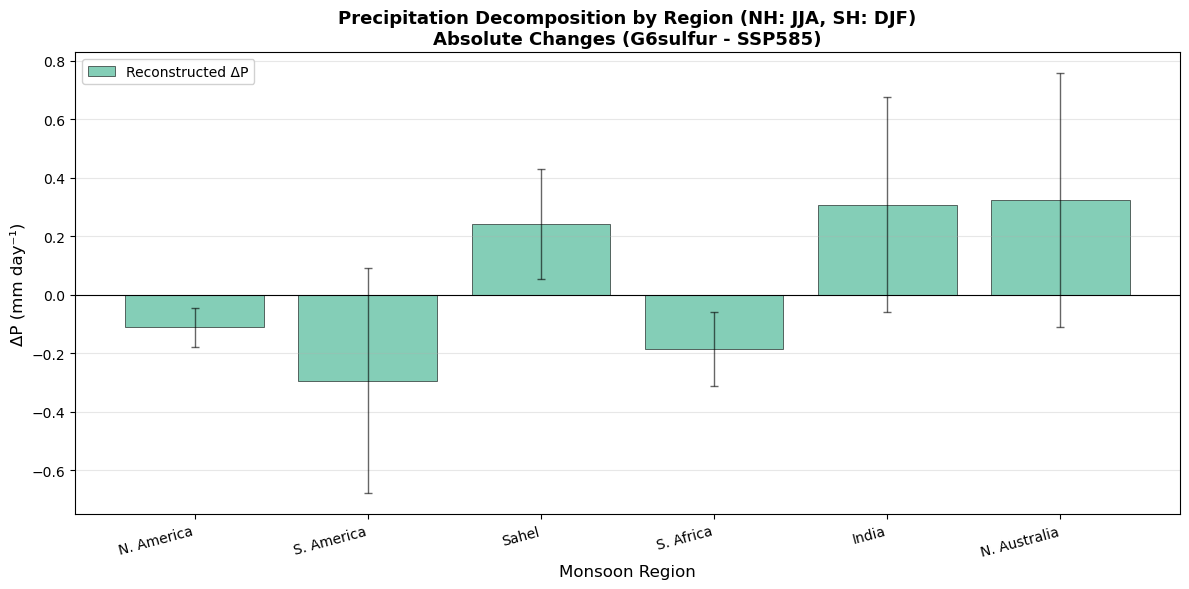

In [29]:
# Example 1: How well does reconstructed ΔP match total ΔP?
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['LHS_delta_P'],
    set_2=['RHS_delta_P_total'],
    season='stitched',
    plot_type='absolute'
)

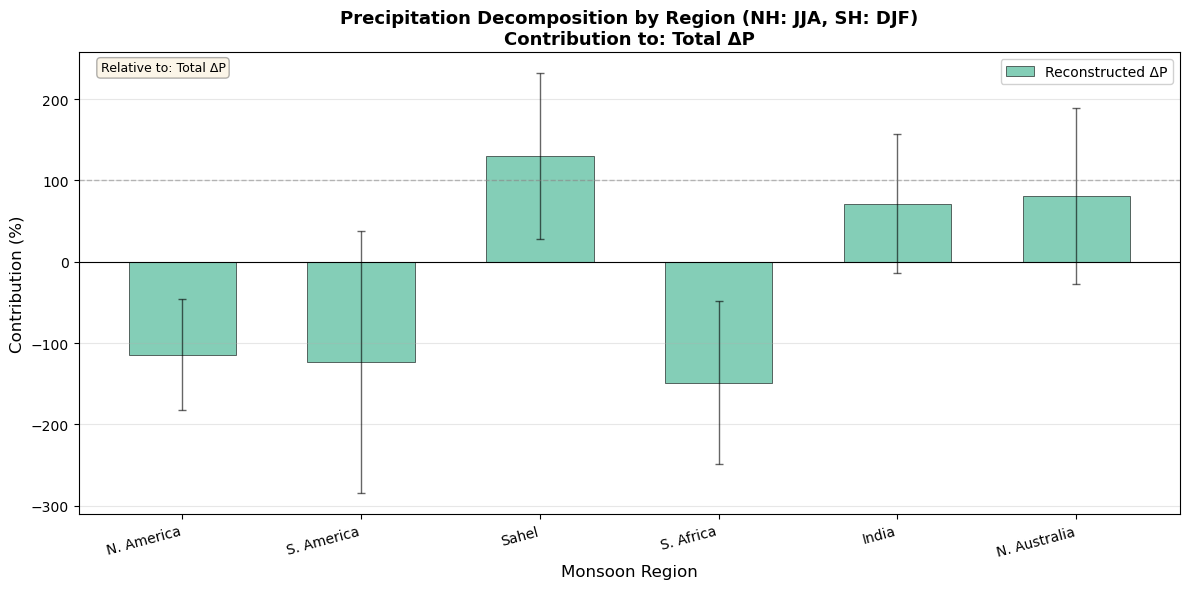

In [27]:
# Example 1: How well does reconstructed ΔP match total ΔP?
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['LHS_delta_P'],
    set_2=['RHS_delta_P_total'],
    season='stitched',
    plot_type='percentage'
)

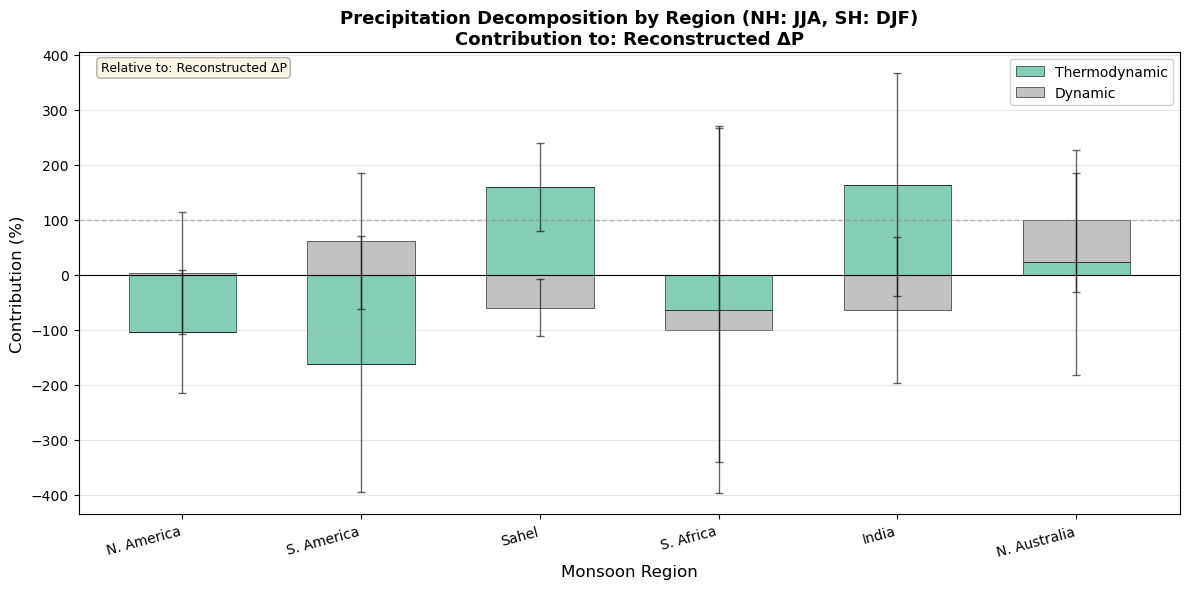

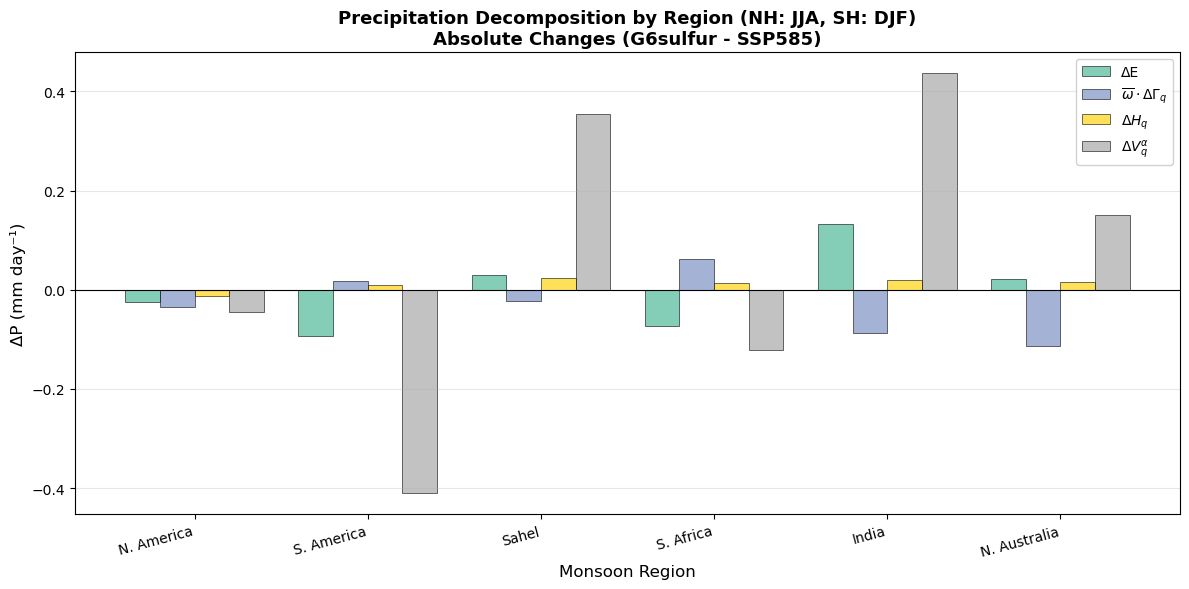

In [28]:


# Example 2: Thermodynamic vs Dynamic contributions to total reconstructed
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['RHS_delta_P_total'],
    set_2=['RHS_delta_P_therm', 'RHS_delta_P_dyn'],
    season='stitched',
    plot_type='percentage'
)

# Example 3: Absolute values of thermodynamic terms
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['RHS_delta_P_therm'],
    set_2=['RHS_therm_delta_E', 'RHS_therm_omega_bar_times_delta_Gamma_q', 
           'RHS_therm_delta_H_q', 'RHS_therm_delta_Valpha_q'],
    season='stitched',
    plot_type='absolute',
    show_error_bars=False #True
)

# # Example 4: Without error bars
# fig, ax, data = plot_regional_decomposition_bars(
#     pr_comp,
#     set_1=['LHS_delta_P'],
#     set_2=['RHS_delta_P_therm', 'RHS_delta_P_dyn'],
#     season='SUM',  # Summer only
#     plot_type='percentage',
#     show_error_bars=False
# )

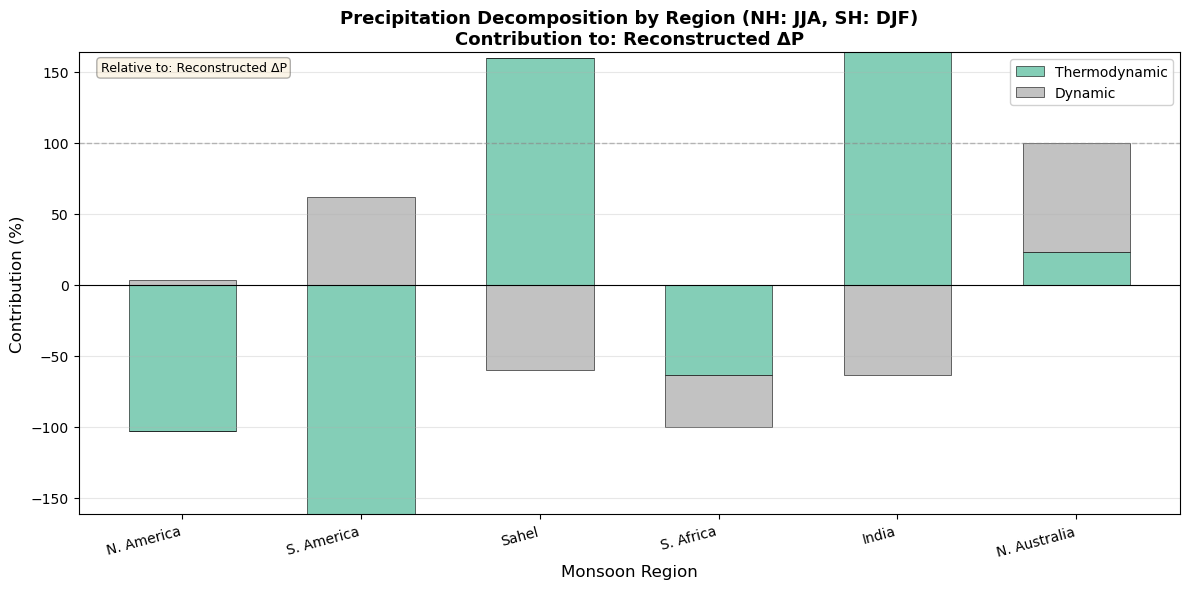

In [24]:
# Example 2: Thermodynamic vs Dynamic contributions to total reconstructed
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['RHS_delta_P_total'],
    set_2=['RHS_delta_P_therm', 'RHS_delta_P_dyn'],
    season='stitched',
    plot_type='percentage',
    show_error_bars=False
)


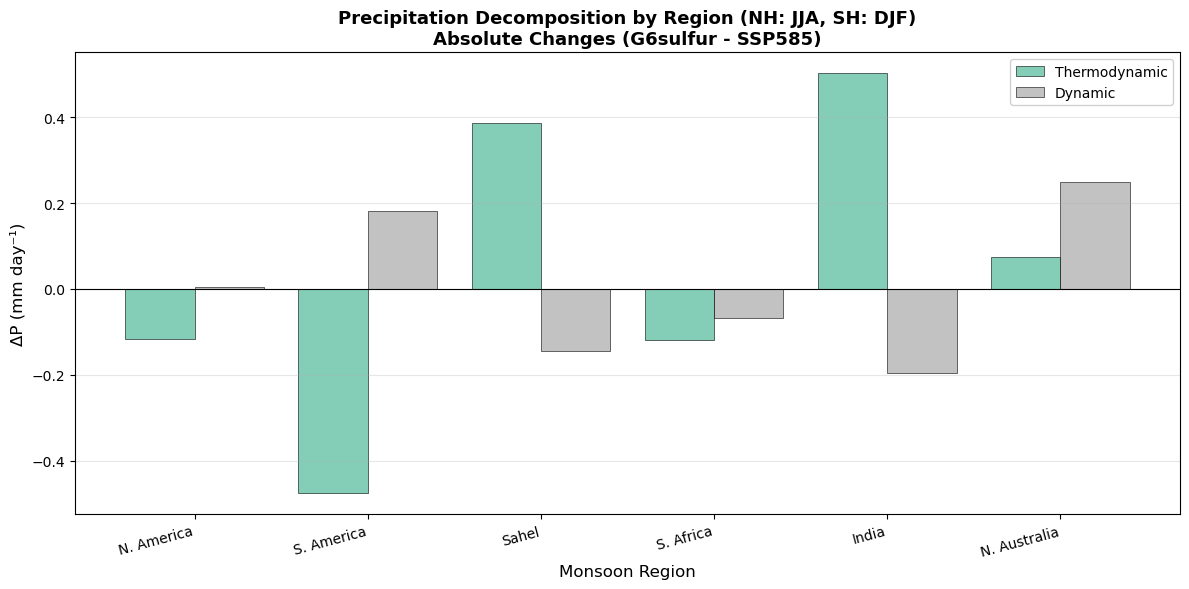

In [25]:
# Example 2: Thermodynamic vs Dynamic contributions to total reconstructed
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['RHS_delta_P_total'],
    set_2=['RHS_delta_P_therm', 'RHS_delta_P_dyn'],
    season='stitched',
    plot_type='absolute',
    show_error_bars=False
)

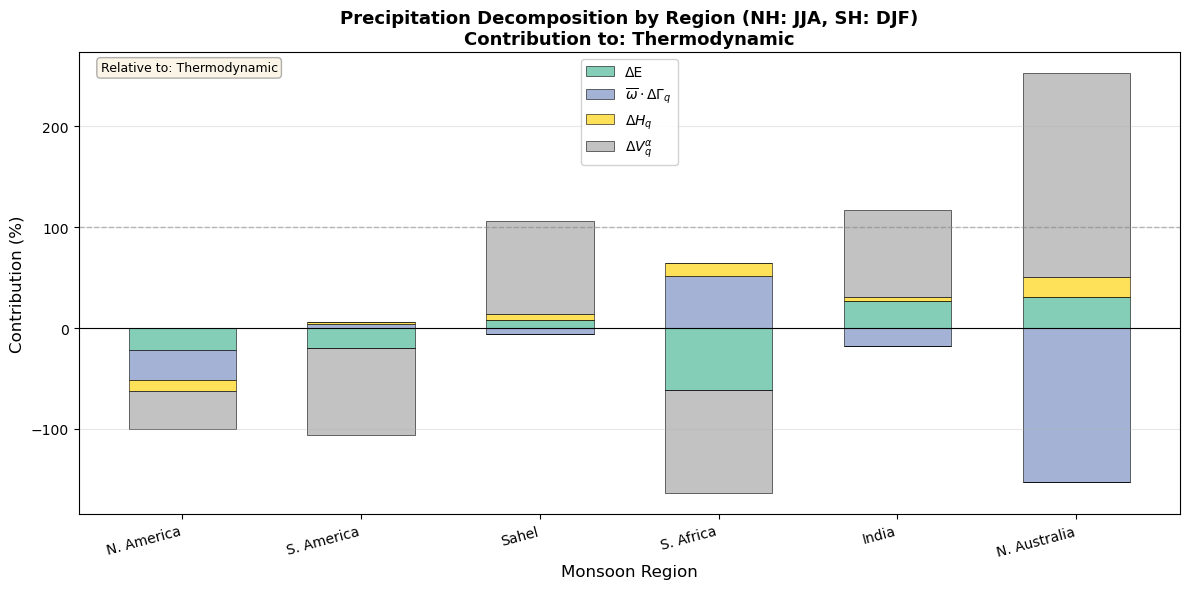

In [26]:
# Example 3: Absolute values of thermodynamic terms
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['RHS_delta_P_therm'],
    set_2=['RHS_therm_delta_E', 'RHS_therm_omega_bar_times_delta_Gamma_q', 
           'RHS_therm_delta_H_q', 'RHS_therm_delta_Valpha_q'],
    season='stitched',
    plot_type='percentage',
    show_error_bars=False #True
)

**ΔVᵅq (Delta Valpha)** is one of the *less intuitive but important* terms in the **Bony et al. (2013)** moisture‑budget decomposition.  
Below is a **clear physical interpretation**, tied directly to the mathematics.

***

## 1. Where ΔVᵅq comes from (context)

Recall the vertical moisture advection term:

$$
-[\omega \,\partial q/\partial p]
$$

Bony et al. decompose the vertical velocity as:

$$
\omega(p) = \underbrace{\bar{\omega}\,\Phi(p)}_{\Omega(p)} \;+\; \underbrace{(\omega - \Omega)}_{\text{deviation}}
$$

This splits vertical moisture transport into:

1.  **Mean‑ascent‑driven part** → goes into **ΔP\_dyn**
2.  **Deviations from the idealized shape** → **Vᵅq**

***

## 2. Mathematical definition of Vᵅq

$$
\boxed{
V^\alpha q
=
-\left[(\omega - \Omega)\,\frac{\partial q}{\partial p}\right]
}
$$

and therefore:

$$
\Delta V^\alpha q
=
V^\alpha q_{\text{G6sulfur}}
-
V^\alpha q_{\text{SSP245}}
$$

***

## 3. Physical meaning (plain language)

### **ΔVᵅq measures changes in how vertical motion is *distributed with height***

—not changes in the *strength* of ascent or descent (that is ΔP\_dyn).

It captures **vertical‑structure effects**, such as:

*   top‑heavy vs bottom‑heavy convection
*   shifts in detrainment level
*   changes in stability (e.g., aerosol‑induced cooling anomalies)
*   changes in where moisture convergence occurs vertically

In short:

> **ΔVᵅq tells you how changes in the *shape* of vertical motion affect precipitation, at fixed mean circulation strength.**

***

## 4. How ΔVᵅq differs from ΔP\_dyn

| Term        | What changes?                | What stays fixed?    |
| ----------- | ---------------------------- | -------------------- |
| **ΔP\_dyn** | Mean vertical mass flux (ω̄) | Vertical structure   |
| **ΔVᵅq**    | Vertical profile of ω        | Mean ascent strength |

ΔVᵅq isolates **baroclinic structure changes**, not circulation amplitude.

***

## 5. Why ΔVᵅq is grouped as *thermodynamic* in Bony et al.

Although it involves ω, Bony et al. place ΔVᵅq in **ΔPₜₕₑᵣ** because:

*   it depends strongly on **∂q/∂p** (moisture stratification)
*   it is sensitive to **thermodynamic vertical structure**
*   it does **not scale with Δω̄**

So:

> ΔVᵅq modifies precipitation through *where* moisture convergence occurs vertically, not *how much* mass ascends.

***

## 6. Physical examples

### Example 1: **Top‑heavy ascent increases**

*   More ascent aloft, less near surface
*   Moisture gradient is weaker aloft
*   → **Precipitation efficiency may decrease**
*   → ΔVᵅq < 0

### Example 2: **Bottom‑heavy ascent strengthens**

*   Convergence moves lower
*   Stronger moisture gradient
*   → **Precipitation increases**
*   → ΔVᵅq > 0

***
***
***
## 7. Why ΔVᵅq is important in **G6sulfur**

Aerosol forcing often causes:

*   stabilization of lower troposphere
*   altered cloud microphysics
*   changes in convective depth

These **strongly affect vertical structure**, even with fixed GMST.

✅ That is why ΔVᵅq is often **non‑negligible in geoengineering experiments**, even when CC scaling is muted.
***
***
***

## 8. One‑sentence takeaway (key)

> **ΔVᵅq represents the contribution of changes in the vertical structure of vertical motion—independent of circulation strength—to precipitation change, acting through moisture stratification.**

***

If you want, I can:

*   show how large ΔVᵅq typically is relative to ΔP\_dyn,
*   help you decide whether it is safe to neglect it in your experiment,
*   or give a schematic you can use in a methods section or presentation.
